# 🏠 [3주차] Ames 집값 EDA & 전처리 의사결정 파이프라인

---

### 과제 설명
미국 아이오와주 에임스市에서 거래된 주택 **1,460건**의 데이터를 가지고, 강의에서 배운 EDA·기술통계를 **직접 적용**하는 작은 프로젝트다. 목표는 "모델을 만드는 것"이 아니라, 데이터를 관찰하고 **"그래서 어떻게 전처리할 것인가"를 스스로 결정**하는 것이다.

### 어떻게 진행되나? (모든 파트가 같은 3단계 반복)
> **① 실습** → **② 해석**  → **③ 의사결정**

`______` 빈칸 또는 `# TODO`로 남겨둔 *빈칸 몇 개와, 그보다 훨씬 중요한 "✍️ 서술형" 답** 를 채워주세요.

### ⚠️ 제출 규칙
1. 모든 `______` 빈칸과 `# TODO`를 채운다.
2. **"✍️ 서술형"** 답은 반드시 **본인 데이터의 실제 수치를 인용**해 작성한다. (예: "SalePrice 왜도가 1.88이므로…")
3. **맨 마지막 셀**에 생성형 AI(GPT/Claude) 사용 내역을 붙여넣는다. (안 썼으면 "사용 안 함")

---
## 0. 환경 설정 & 데이터 로드

아래 셀들을 순서대로 실행한다. 라이브러리를 불러오고, 인터넷에서 데이터를 바로 읽어온다. (별도 파일 업로드 불필요)

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

plt.rcParams['axes.unicode_minus'] = False
sns.set_theme(style="whitegrid")
pd.set_option('display.max_columns', 100)
print("라이브러리 준비 완료 ✅")

# 경고문이 많이 떠서 이를 방지하기 위해 새로 첨가했습니다
import warnings
warnings.filterwarnings('ignore')
# 한글 깨짐 방지
plt.rcParams['font.family'] = 'malgun gothic'

라이브러리 준비 완료 ✅


In [2]:
# 데이터 불러오기: Ames Housing (1460행 × 81열)
URL = "https://raw.githubusercontent.com/hjhuney/Data/master/AmesHousing/train.csv"
df = pd.read_csv(URL)

print("데이터 크기 (행, 열):", df.shape)
df.head()

데이터 크기 (행, 열): (1460, 81)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


> **데이터 설명**: 한 행(row)이 주택 1채의 거래 기록이다. 예측 대상(타깃)은 `SalePrice`(판매가, 달러)이고, 나머지 79개 컬럼이 그 집의 특징(면적·품질·동네·차고 등)이다.

---
# Part 1. 데이터 타입의 정렬 — dtype vs 실제 의미

> ① 실습: `info()`·`describe()`로 전체를 보고, `MSSubClass`의 기술통계를 확인
> ② 해석: 컴퓨터가 '숫자'로 읽은 변수가 정말 사칙연산이 되는 변수인지 비판적으로 검토
> ③ 의사결정: 인코딩 전략을 결정

In [3]:
# ① 전체 형태 확인
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [4]:
# 수치형 변수들의 요약 통계
df.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,TotRmsAbvGrd,Fireplaces,GarageYrBlt,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1379.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,46.549315,567.240411,1057.429452,1162.626712,346.992466,5.844521,1515.463699,0.425342,0.057534,1.565068,0.382877,2.866438,1.046575,6.517808,0.613014,1978.506164,1.767123,472.980137,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,161.319273,441.866955,438.705324,386.587738,436.528436,48.623081,525.480383,0.518911,0.238753,0.550916,0.502885,0.815778,0.220338,1.625393,0.644666,24.689725,0.747315,213.804841,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,0.000000,0.000000,0.000000,334.000000,0.000000,0.000000,334.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,1900.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,0.000000,223.000000,795.750000,882.000000,0.000000,0.000000,1129.500000,0.000000,0.000000,1.000000,0.000000,2.000000,1.000000,5.000000,0.000000,1961.000000,1.000000,334.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,0.000000,477.500000,991.500000,1087.000000,0.000000,0.000000,1464.000000,0.000000,0.000000,2.000000,0.000000,3.000000,1.000000,6.000000,1.000000,1980.000000,2.000000,480.000000,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,0.000000,808.000000,1298.250000,1391.250000,728.000000,0.000000,1776.750000,1.000000,0.000000,2.000000,1.000000,3.000000,1.000000,7.000000,1.000000,2002.000000,2.000000,576.000000,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,1474.000000,2336.000000,6110.000000,4692.000000,2065.000000,572.000000,5642.000000,3.000000,2.000000,3.000000,2.000000,8.000000,3.000000,14.000000,3.000000,2010.000000,4.000000,1418.000000,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [15]:
# MSSubClass(주택 유형 코드)는 숫자로 저장돼 있다. 직접 확인해보자.

# TODO: dtype, 평균, 고유값을 출력하라
print("MSSubClass dtype :", df['MSSubClass'].dtype)           # 저장 타입
print("MSSubClass 평균  :", round(df['MSSubClass'].mean(), 2))  # 평균 계산
print("MSSubClass 고유값:", sorted(df['MSSubClass'].unique()))  # 고유값 목록
# 출력 결과를 보고 이 변수의 평균값이 의미 있는 숫자인지 생각해보자

MSSubClass dtype : int64
MSSubClass 평균  : 56.9
MSSubClass 고유값: [20, 30, 40, 45, 50, 60, 70, 75, 80, 85, 90, 120, 160, 180, 190]


**✍️ 서술형 Part 1**

**Q1.** `MSSubClass`의 평균값(위 출력)이 통계적으로 무의미한 이유를, 변수의 척도(명목/순서/등간/비율) 개념과 연결해 설명하세요. 그리고 모델이 이 변수를 크기가 있는 숫자로 오해하지 않도록 **어떤 인코딩**을 적용할지 결정하세요.
→ **답:** ______

**Q2.** 두 범주형 변수 `ExterQual`(외관 품질: Ex>Gd>TA>Fa>Po, 순서 있음)과 `Neighborhood`(동네 이름, 순서 없음)를 숫자로 바꾸려 합니다. 각각 **Ordinal 인코딩**과 **One-Hot 인코딩** 중 무엇을 써야 하며 그 이유는 무엇인가요? (힌트: 순서 정보가 있는가?)
→ **답:** ______

**A1.** 
MSSubClass는 주택 유형 코드로써 주택 유형 자체를 특정한다. 따라서 이는 종류를 구분하는 것이지 그 크기 자체가 특정한 의미를 띄고 있다고 말하기 어렵다. 이는 명목 척도로써 단순 거주지를 분류하기 위한 척도에 불과하기 때문에 발생하는 문제이다. 보통 이렇게 명목척도에 대해서는 One-Hot Encoding을 수행하지만 MSSubClass처럼 범주가 과하게 많을 수 있는 경우 상위 n개만을 남기고 진행하는 방식으로 binary 변수의 가짓수를 통제해 over fitting을 방지하는 방식으로 진행한다

**A2.**
ExterQual은 외관 품질의 grade가 정해져 있기 때문에 Ordinal Encoding을 채택해야한다.
Neighvorhood는 동네 이름을 뜻하고 각각이 범주 자체를 의미하기 때문에 One-Hot Encoding을 진행해야 적절히 범주형 변수를 숫자로 변환할 수 있다.

---
# Part 2. Target 변수의 분포와 변환 전략

> ① 실습: `SalePrice`의 히스토그램·왜도·첨도, 그리고 `LotArea`의 평균 vs 중앙값
> ② 해석: 꼬리가 어디로 치우쳤는지, 평균-중앙값 격차가 무엇을 뜻하는지 파악
> ③ 의사결정: 로그 변환 필요 여부, 대표값 선택

평균  : 180,921
중앙값: 163,000
왜도  : 1.88
첨도  : 6.54


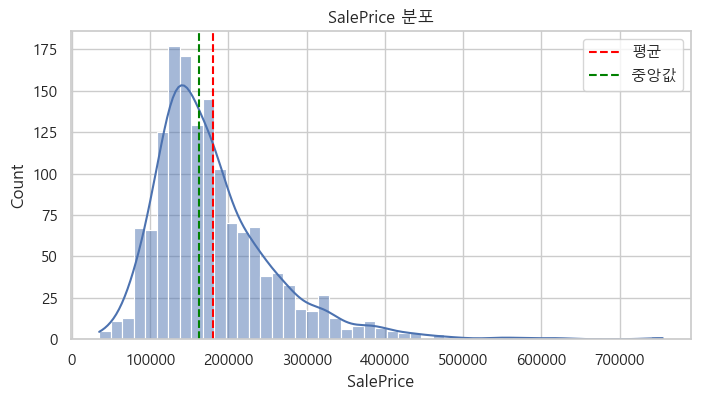

In [21]:
# ① SalePrice 분포 진단
sp = df['SalePrice']

# TODO: 왜도(skewness)와 첨도(kurtosis)를 구하라  (힌트: 시리즈의 .skew() , .kurt())
skew_ = sp.skew()
kurt_ = sp.kurt()

print(f"평균  : {sp.mean():,.0f}")
print(f"중앙값: {sp.median():,.0f}")
print(f"왜도  : {skew_:.2f}")
print(f"첨도  : {kurt_:.2f}")

plt.figure(figsize=(8,4))
sns.histplot(sp, kde=True)
plt.axvline(sp.mean(),   color='red',   ls='--', label='평균')
plt.axvline(sp.median(), color='green', ls='--', label='중앙값')
plt.title('SalePrice 분포'); plt.legend(); plt.show()

In [22]:
# LotArea(부지 면적)의 평균 vs 중앙값 비교
print(f"LotArea 평균  : {df['LotArea'].mean():,.0f}")
print(f"LotArea 중앙값: {df['LotArea'].median():,.0f}")
print(f"LotArea 최댓값: {df['LotArea'].max():,.0f}  <- 극단값 확인")

LotArea 평균  : 10,517
LotArea 중앙값: 9,478
LotArea 최댓값: 215,245  <- 극단값 확인


**✍️ 서술형 Part 2**

**Q1.** `SalePrice`의 왜도 부호와 분포 꼬리 방향(좌왜/우왜)을 쓰고, 이 분포를 선형 모델에 넣을 때 어떤 변환(예: 로그 변환)이 필요한지 결정하세요. 변환한다면 왜도 수치가 어떻게 변할지도 예측해보세요.
→ **답:** ______

**Q2.** `LotArea`의 평균과 중앙값 중, 현재 데이터의 '대표값'으로 더 적절한 것은? 극단적 이상치가 통계량에 미치는 영향을 근거로 방어하세요.
→ **답:** ______

**A1.**
right-skewed 꼴을 띄고 있다. 이 분포를 모델에 넣을 때는 log1p transformation을 적용해 skewness를 줄여줘야한다. 변환하면 기존의 양의 왜도를 띄고 있던 수치에서 0에 가깝게 감소하여 normal distribution 처럼 bell shape을 이쁘게 띄고 있는 형태로 변환될 것으로 예측된다.

**A2.**
반드시 중앙값이 적합하다.이처럼 skewness가 크고 outlier가 데이터에 미칠 영향이 확실한 상태에서 mean을 대푯값으로 사용하게 되면 데이터의 분포를 왜곡시킬 가능성이 매우 높다. 따라서 median을 채택해 데이터의 대표값으로 이용하는 것이 합리적이다.

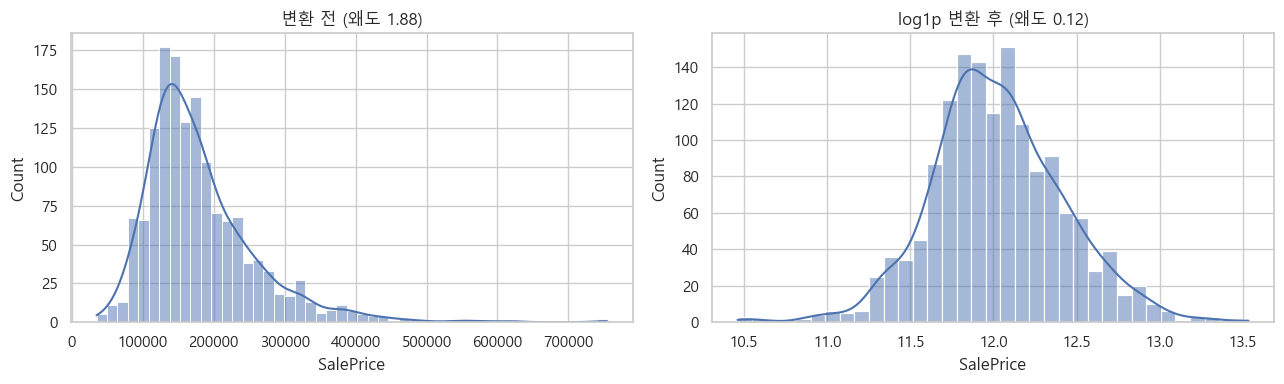

변환 후 왜도가 0에 가까워졌는가? 0.121


In [23]:
# ③ 로그 변환을 직접 적용해 예측이 맞았는지 확인
sp_log = np.log1p(sp)   # log1p = log(1+x), 0이 있어도 안전

fig, ax = plt.subplots(1, 2, figsize=(13,4))
sns.histplot(sp,     kde=True, ax=ax[0]); ax[0].set_title(f'변환 전 (왜도 {sp.skew():.2f})')
sns.histplot(sp_log, kde=True, ax=ax[1]); ax[1].set_title(f'log1p 변환 후 (왜도 {sp_log.skew():.2f})')
plt.tight_layout(); plt.show()
print("변환 후 왜도가 0에 가까워졌는가?", round(sp_log.skew(), 3))

---
# Part 3. 결측치 비율에 따른 입체적 대체 전략 🔥

> ① 실습: 결측 컬럼과 비율을 내림차순 테이블로
> ② 해석: 높은 결측(FireplaceQu)·애매한 결측(LotFrontage)·0 밀집(MasVnrArea)의 맥락 유추
> ③ 의사결정: 컬럼마다 다른 처방을 설계

이 파트가 이번 과제의 **변별력 구간**입니다. "결측이면 무조건 채운다/버린다"가 아니라, 결측이 왜 생겼는지에 따라 처방이 달라집니다.

In [24]:
# ① 결측 비율(%) 내림차순
miss = (df.isnull().mean()*100).sort_values(ascending=False)
miss = miss[miss > 0].round(1)
print("결측이 있는 컬럼 수:", len(miss))
miss.head(20)

결측이 있는 컬럼 수: 19


PoolQC          99.5
MiscFeature     96.3
Alley           93.8
Fence           80.8
MasVnrType      59.7
FireplaceQu     47.3
LotFrontage     17.7
GarageYrBlt      5.5
GarageCond       5.5
GarageType       5.5
GarageFinish     5.5
GarageQual       5.5
BsmtFinType2     2.6
BsmtExposure     2.6
BsmtQual         2.5
BsmtCond         2.5
BsmtFinType1     2.5
MasVnrArea       0.5
Electrical       0.1
dtype: float64

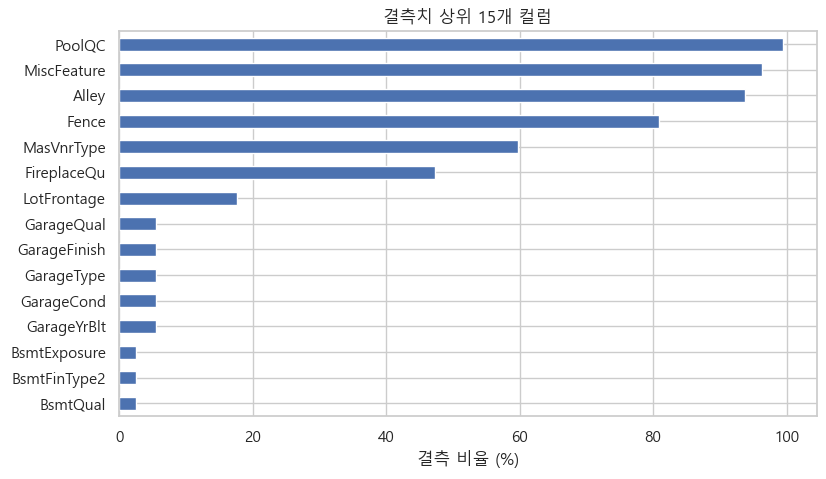

In [29]:
# 결측 비율 상위 시각화
plt.figure(figsize=(9,5))
miss.head(15).sort_values().plot(kind='barh')
plt.xlabel('결측 비율 (%)'); plt.title('결측치 상위 15개 컬럼'); plt.show()

In [36]:
# ② 세 변수의 맥락을 조사해보자
# (a) FireplaceQu(벽난로 품질)가 결측인 집의 Fireplaces(벽난로 개수)는?
print("[FireplaceQu 결측 행의 벽난로 개수]")
print(df.loc[df['FireplaceQu'].isnull(), 'Fireplaces'].value_counts(), "\n")

# (b) MasVnrArea(조적 베니어 면적)의 값 분포 — 0이 얼마나 몰려있나?
# 힌트: 0인지 아닌지를 True/False(=1/0)로 변환 → 합산하면 0의 개수, 평균내면 0의 비율
print("[MasVnrArea] 결측 개수:", df['MasVnrArea'].isnull().sum(),
      "| 값이 0인 비율: %.1f%%" % ((df['MasVnrArea'] == 0).mean() * 100))

# (c) LotFrontage 결측을 전체 중앙값 하나로 채우면 동네마다 도로 폭이 다른데도
# 모든 집에 같은 값이 들어간다. 동네별로 중앙값이 실제로 다른지 확인해보자. >> 도구 : groupby
# TODO: 동네(Neighborhood)를 기준으로 묶어 LotFrontage의 중앙값을 구하라
print("[동네별 LotFrontage 중앙값 (일부)]")
print(df.groupby('Neighborhood')['LotFrontage'].median().dropna().head(6))

[FireplaceQu 결측 행의 벽난로 개수]
Fireplaces
0    690
Name: count, dtype: int64 

[MasVnrArea] 결측 개수: 8 | 값이 0인 비율: 59.0%
[동네별 LotFrontage 중앙값 (일부)]
Neighborhood
Blmngtn    43.0
Blueste    24.0
BrDale     21.0
BrkSide    52.0
ClearCr    80.0
CollgCr    70.0
Name: LotFrontage, dtype: float64


**✍️ 서술형 Part 3**

**Q1 [구조적 결측].** `FireplaceQu`는 결측률이 약 47%지만, 위 (a)에서 보듯 결측 행은 전부 벽난로 개수가 0이다. 즉 결측이 아니라 **'벽난로 없음'이라는 정보**다. 이 컬럼을 그냥 '열 삭제'하면 왜 위험한가요? 데이터를 보존하는 본인만의 처리법(예: `'None'` 범주 부여)을 제시하세요.
→ **답:** ______

**Q2 [0 밀집 분포].** `MasVnrArea`는 값의 약 59%가 0(=베니어 없음)이다. 이 소수의 결측(8건)을 **'0을 포함한 전체 평균값'**으로 채우면 어떤 왜곡이 생기는가? 더 안전한 대안은?
→ **답:** ______

**A1.**
일단 결측치에는 여러 종류가 존재한다 MCAR, MAR, MNAR 크게 세가지 종류가 존재하는데 이렇게 그냥 열 삭제를 진행하는 것은 완전 무작위 결측 즉, MCAR에서도 그 무작위성이 확실하거나 결측 비율이 극히 작은 경우에만 진행하는 매우 급진적인 방법이다. 따라서 해당 데이터를 보존하기 위해서 제가 주로 사용했던 방법은 missing indicator를 첨가해서 진행하는 것이다. 새로운 missing indicator column을 하나 만들어서 원래 값이 있었으면 1 없었으면 0을 배부해 진행하고 모델 자체가 알아서 그 중요도를 판단하게 진행한다. 다만 이와 같이 도메인 지식이 확실하고 벽난로 없음을 의미한다는 것이 확실할 때는 결측치를 실제로 채워넣기도 했다 ^^

**A2.**
가장 큰 문제는 binary 변수인데 연속형 변수처럼 값을 띄게 된다는 것이다. 이 결측치도 binary 변수에 가하는 작용처럼 0 또는 1로 처리되어서 해결되어야 하는데 이렇게 되면 소수점을 띄고 있는 값으로 채워지게 되어 왜곡되게된다. 따라서 이 경우 무난하게는 최빈값으로 채워넣거나 더 안전한 대안으로는 K-NN을 통해 해당 결측치가 다른 데이터의 특성으로 미루어봤을때 어디에 해당할 것 같은가?로 채워넣는게 좋아보인다.

---
# Part 4. 의미 있는 이상치와 파생 변수의 부작용

> ① 실습: `GrLivArea` vs `SalePrice` 산점도에서 이상 패턴 포착, `Total_Area` 파생 변수 생성
> ② 해석: 포착된 점이 수집 오류(Noise)인지 실제 거래(의미 있는 이상치)인지 추론
> ③ 의사결정: 제거할지 유지할지, 파생 변수의 부작용 대응

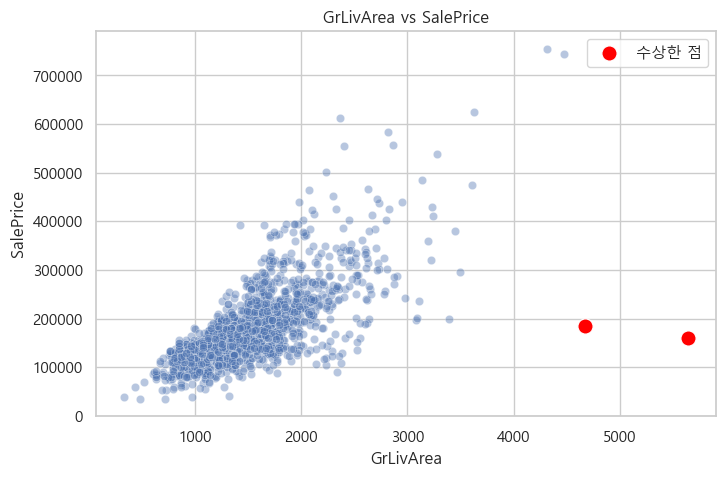

수상한 점 개수: 2
      GrLivArea  SalePrice  OverallQual SaleCondition
523        4676     184750           10       Partial
1298       5642     160000           10       Partial


In [41]:
# ① 산점도로 이상 패턴 찾기
plt.figure(figsize=(8,5))
# TODO: 두 변수의 관계를 산점도로 그려라
sns.scatterplot(data=df, x='GrLivArea', y='SalePrice', alpha=0.4)

# 면적은 아주 큰데(>4000) 가격은 낮은(<200000) 수상한 점을 빨간색으로
weird = df[(df['GrLivArea'] > 4000) & (df['SalePrice'] < 200000)]
# TODO: 위에서 걸러낸 이상점을 빨간색으로 덧그려라
sns.scatterplot(data=weird, x='GrLivArea', y='SalePrice', color='red', s=120, label='수상한 점')
plt.title('GrLivArea vs SalePrice'); plt.legend(); plt.show()

print(f"수상한 점 개수: {len(weird)}")
print(weird[['GrLivArea','SalePrice','OverallQual','SaleCondition']])

In [42]:
# ③ 여러 면적 변수를 더해 Total_Area 파생 변수 생성
df['Total_Area'] = df['1stFlrSF'] + df['2ndFlrSF'] + df['TotalBsmtSF']

# 새 변수와 기존 변수들의 상관을 확인
print(df[['Total_Area','1stFlrSF','2ndFlrSF','TotalBsmtSF','SalePrice']].corr()['SalePrice'].round(3))

Total_Area     0.782
1stFlrSF       0.606
2ndFlrSF       0.319
TotalBsmtSF    0.614
SalePrice      1.000
Name: SalePrice, dtype: float64


**✍️ 서술형 Part 4**

**Q1 [이상치 판단].** 빨간 점 2개는 `SaleCondition`이 `Partial`(미완공 상태 거래)이다. 이들을 **노이즈로 보고 완전히 제거**할 것인가, 아니면 **유지하되 이상치에 강건한 트리 계열 모델**을 쓸 것인가? 본인의 결정 논리를 서술하라.
→ **답:** 

**Q2 [다중공선성].** `Total_Area`는 `1stFlrSF + 2ndFlrSF + TotalBsmtSF`의 합이라, 이 셋과 거의 완벽하게 겹친다(위 상관 확인). 파생 변수와 원본 3개를 **모두** 모델에 넣으면 왜 문제가 되는가? (힌트: 서로 강하게 상관된 변수를 중복 투입 = 다중공선성) 원본을 유지할지 삭제할지 결정하라.
→ **답:** 

**A1.**
미완공 상태 거래인 경우인 점이 두 점만 매우 적은 비율로 존재하며 완공되지도 않았는데 판매되는 논리가 부족하다고 생각되어 완전히 제거하고 사용하는 것이 좋을 것 같다고 생각된다. 

**A2.**
multicollinearity는 coefficient의 robustness를 강하게 망가뜨릴수 있다. 작은 값의 변동만으로 전체 데이터의 움직임을 크게 뒤흔들 수 있어 문제가 된다. 또한 해당 변수들은 겹치는 모델의 inform을 갖고 있기 때문에 모델 자체의 SE가 그 변수에 의해 견인될 수 있다. 따라서 CI가 크게 넓어지거나 좁아지거나 그 변수 묶음에 의해 크게 좌지우지될 수 있다. 이외에도 다양한 심각한 문제가 존재하지만 위 두개가 가장 직접적인 문제다. 당연히 원본을 삭제하는 방향으로 수정에 들어가야한다. 

---
# Part 5. 다변량 관계의 함정과 Target Leakage

> ① 실습: 수치형 상관 히트맵 + 범주형은 Boxplot으로
> ② 해석: 히트맵에 범주형(동네 등)의 영향력이 누락됨을 인지
> ③ 의사결정: 분석의 맹점, Target Leakage 필터링

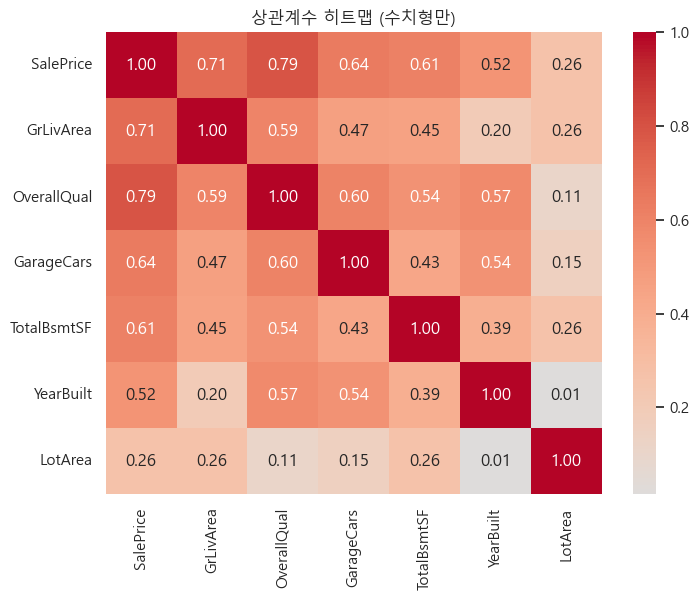

In [43]:
# ① 수치형 상관 히트맵
key = ['SalePrice','GrLivArea','OverallQual','GarageCars','TotalBsmtSF','YearBuilt','LotArea']
plt.figure(figsize=(8,6))
# TODO: 상관계수 행렬을 구하고 히트맵으로 그려라
sns.heatmap(df[key].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('상관계수 히트맵 (수치형만)'); plt.show()

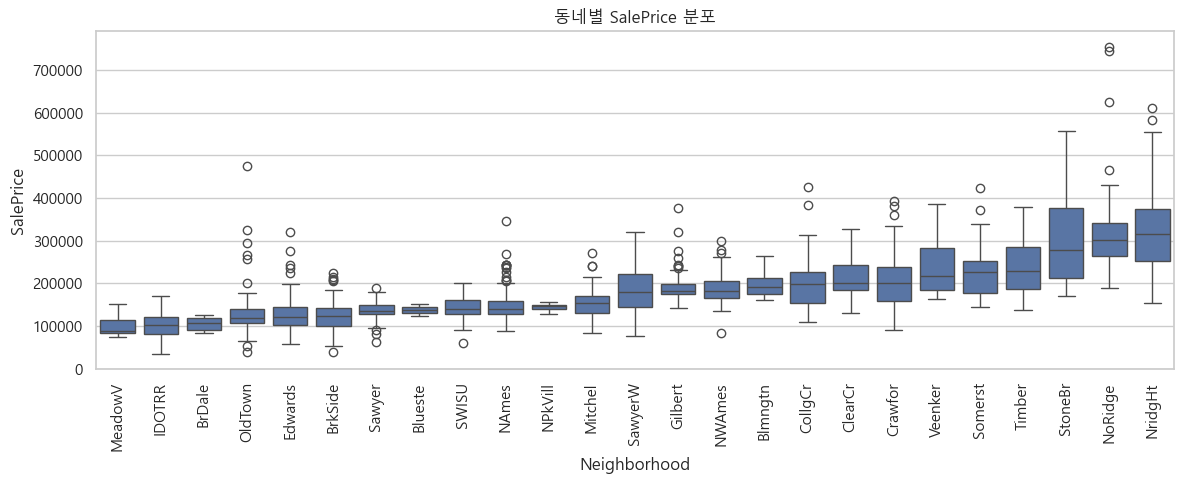

가장 싼 동네 중앙값 88,000 vs 가장 비싼 동네 315,000  (3.6배)


In [44]:
# 히트맵엔 없는 범주형 Neighborhood(동네)의 영향력을 Boxplot으로
order = df.groupby('Neighborhood')['SalePrice'].median().sort_values().index
plt.figure(figsize=(12,5))
# TODO: 동네별 SalePrice 분포를 박스플롯으로 그려라
sns.boxplot(data=df, x='Neighborhood', y='SalePrice', order=order)
plt.xticks(rotation=90); plt.title('동네별 SalePrice 분포'); plt.tight_layout(); plt.show()

nb = df.groupby('Neighborhood')['SalePrice'].median()
print(f"가장 싼 동네 중앙값 {nb.min():,.0f} vs 가장 비싼 동네 {nb.max():,.0f}  ({nb.max()/nb.min():.1f}배)")

**✍️ 서술형 Part 5**

**Q1 [분석의 맹점].** 위 수치형 히트맵만 보고 "집값에 영향을 주는 건 이 수치형 변수들뿐"이라고 결론 내리면 무엇을 놓치는가? Boxplot에서 드러난 `Neighborhood`의 영향력을 근거로, 강의에서 배운 **히트맵의 3가지 맹점 중 어느 것**에 해당하는지 짚어라.
→ **답:** ______

**Q2 [Target Leakage].** 데이터에 '판매 직전 납부한 취등록세액' 변수가 있고 `SalePrice`와 상관이 0.99라고 하자. 취등록세는 보통 판매가에 비례해 매겨진다. 이 변수를 피처에서 **제외해야 하는 이유**를 Target Leakage 관점에서 설명하라. (힌트: 집을 팔기 *전에* 알 수 있는 값인가?)
→ **답:** ______

**A1.**
수업 때 배운 내용 중 범주형의 부재로 인한 문제가 발생한다. 히트맵은 문제에 명시되어 있듯이 수치형만을 나타내고 있기 때문에 이 점을 놓치기 쉽다. 따라서 영향력이 큰 Neighborhood의 영향을 놓치기 쉬워 이를 유의해서 진행해야한다.

**A2.**
target leakage는 맞춰야 되는 정답이 훈련과정에서 섞여들어가는 것을 의미한다. 취등록세액은 집을 팔기 전에는 알 수 없고 집을 판매한 후에야 알 수 있는 관련 값이기 때문에 해당 변수가 훈련과정에서 섞여들어가게 되면 모델의 성능이 오인될 수 있다. 

---
# Part 6. 데이터 누수 없는 파이프라인 (심화·선택)

> ① 실습: Train/Test 분할 후, 대체·스케일링 코드의 TODO를 채워 올바르게 작동시키기
> ② 해석: "Train 통계로 Test를 채운다"는 원리와 정보 유출의 차이
> ③ 의사결정: 분할을 '가장 먼저' 해야 하는 원칙 선언

In [45]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

# 간단히 수치형 변수 몇 개만 사용
feats = ['GrLivArea','OverallQual','TotalBsmtSF','GarageCars','LotFrontage']
X = df[feats].copy()
y = np.log1p(df['SalePrice'])

# 1) 가장 먼저 Train/Test 분할  (random_state는 본인 학번 뒤 4자리로!)
# TODO: 아래 ______ 에 본인 학번 앞 4자리 (예: 2021학번이면 2021)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state= 2021)

# 2) 결측 대체: Train 에서 fit, Test 에는 transform 만
imp = SimpleImputer(strategy='median')

# 추가공부
# 결측치 처리에서 simpleimputer는 결측치를 strategy에 해당되는 값으로 채우는 것을 의미한다.

# 연산량 문제가 아래는 모두 존재해서 조심해서 기용한다..
# KNN imputer은 결측치가 있는 데이터에 유사한 k개의 데이터를 찾아 채워넣는 방식
# iterative imputer은 결측치를 iteration해서 결측치와 예측값이 수렴할 때까지 업데이트
# Miceforest(최신 애용되는 algo로 안다.) linear reg 대신 RF를 사용하는 방식


X_train_imp = imp.fit_transform(X_train)          # fit_transform: Train 통계를 '학습'하며 변환
# TODO: Test 는 새로 fit 하지 말고, Train 이 학습한 값으로 transform 만 하라
X_test_imp  = imp.transform(X_test)

# 3) 스케일링도 동일 원칙 (Train 에서만 fit)
sc = StandardScaler()

# 추가공부 
# 내가 애용햇던 것은 RobustScaler였다. 
# 해당 StanderScaler은 stat의 standardization으로 이해하면 좋다.

X_train_sc = sc.fit_transform(X_train_imp)
# TODO: Test 스케일링 (transform 만)
X_test_sc  = sc.transform(X_test_imp)

print("완료 — Train:", X_train_sc.shape, "/ Test:", X_test_sc.shape)
print("Train 중앙값으로 채운 LotFrontage 대체값:", round(imp.statistics_[feats.index('LotFrontage')], 1))

완료 — Train: (1168, 5) / Test: (292, 5)
Train 중앙값으로 채운 LotFrontage 대체값: 69.0


**✍️ 서술형 Part 6**

**Q1.** Test 데이터에 `fit`(또는 `fit_transform`)을 하면 안 되는 이유를, "Test는 미래에 들어올 미지의 데이터"라는 관점에서 설명하세요. Test의 통계(평균·중앙값)를 미리 들여다보면 무엇이 새어나갈까요?
→ **답:** ______

**Q2.** 결측 대체·스케일링 같은 전처리보다 **Train/Test 분할을 반드시 먼저** 해야 하는 본인의 행동 원칙을, 데이터 누수 방지 측면에서 말해주세요.
→ **답:** ______

**A1.**
fit을 하거나 fit하고 transform을 하는 것이 바로 data leakage에 직접적으로 해당된다. test는 모델의 성능을 평가하기 위해 분리해놓는 정답의 미지 데이터인데 이를 미리 통계적으로 들여다보면 정답과 관련된 힌트가 새어나간다. 직접적으로 뭐가 문제라고 답하기 힘들정도로 그냥 총체적 난국이다.

**A2.**
결측 대체나 스케일링 같은 전처리는 전체 보유하고 있는 데이터의 특성을 바탕으로 진행되는데 정답 label을 분리해서 진행하지 않으면 이 정답 label이 전처리 과정에서 train안에 섞여서 오염시킬 수 있다. 예를 들면 결측치를 SimpleImputer과 같은 방식으로 채우는 과정에서 mean을 정답이 견인할 수도 있다. 따라서 반드시 태초에 train, test를 분할해서 진행해야한다.

---
# 📌 [필수] 생성형 AI 활용 방법

이 과제를 풀며 GPT/Claude 등을 **어디에, 어떻게** 썼는지 기록한다. (안 썼으면 "사용 안 함")


**답변**

- **활용한 부분:** 이상점을 덧붙여서 색칠하는게 기억이 안나서 그 부분만 어떻게 해야할지 물어봤습니다.
- **대화 내역:**

---
# 🪞 회고
- 가장 어려웠던 부분과 이유:

A.

- 강의 땐 이해했다고 생각했지만 직접 해보며 새로 깨달은 점:

A.
